https://www.kaggle.com/datasets/mrsimple07/student-exam-performance-prediction

In [ ]:
#Import the library and load data set
import numpy as nm
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv('student_exam_data.csv')
df


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
...,...,...,...
495,4.180170,45.494924,0
496,6.252905,95.038815,1
497,1.699612,48.209118,0
498,9.769553,97.014241,1


In [ ]:
#selects the feature columns (study hours and previous exam score) and the target column
x = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [ ]:
#split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [ ]:
#scale the feature values so they are on a similar range
from sklearn.preprocessing import StandardScaler
st_x=StandardScaler()
x_train=st_x.fit_transform(x_train)
x_test=st_x.transform(x_test)

In [ ]:
#create and train the logistic regression model
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)

LogisticRegression(random_state=0)

In [ ]:
#predict the results
y_pred=classifier.predict(x_test)

In [ ]:
#check accuracy of the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy}")

Accuracy of the model: 0.864


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


In [ ]:
#print the results
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Precision: 0.9
Recall: 0.7346938775510204
F1-score: 0.8089887640449438


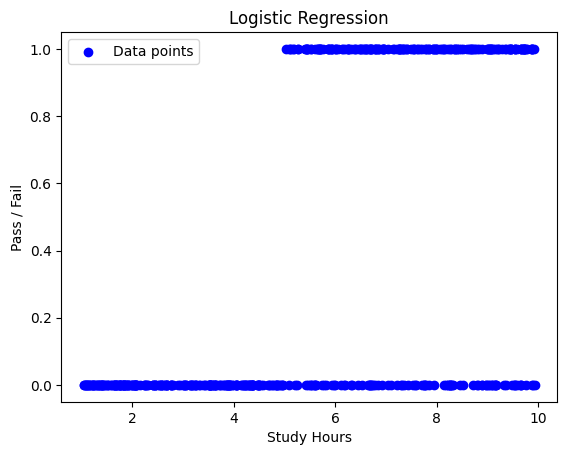

In [ ]:


plt.scatter(df['Study Hours'], df['Pass/Fail'], color='blue', label='Data points')

plt.xlabel('Study Hours')
plt.ylabel('Pass / Fail')
plt.title('Logistic Regression')

plt.legend()
plt.show()


In [ ]:
#allow users to enter values and see a prediction
while True:
  try:
    study_hours = int(input("Enter Study Hours: "))
    previous_exam_score = int(input("Enter Previous Exam Score"))

    new_data_point = nm.array([[study_hours, previous_exam_score]])
    new_data_point = st_x.transform(new_data_point)

    prediction = classifier.predict(new_data_point)

    if prediction[0] == 0:
      print("Prediction: Fail")
    else:
      print("Prediction: Pass")

    break

  except ValueError:
    print("Invalid input. Please enter valid numeric values for Study Hours and Previous Exam Score.")
  except Exception as e:
    print(f"An error occured: {e}")

Enter Study Hours: 100
Enter Previous Exam Score10
Prediction: Pass


This lab uses binary logistic regression model to predict whether a student will pass or fail an exam based on study hours and previous exam score. The dataset was split up into a training and testing data which was scaled so the feaure values were on a similar range. After the model was trained, accuracy, precision, recall and f1 score were calculated to see how well the predictions performed. A graph was also created to show the relationship between study hours and whether the student passed or failed.